In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import os
from voluntary_fixation.envs import TR, MOVIE_FPS, EYEMOVE_ROOT, SAVE_ROOT, SUBJECT_IDS

SAVE_ROOT = '../../' + SAVE_ROOT
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 17 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 17 # 軸だけ変更されます

In [22]:

iou_q = 0.5
saliency_TR_q = 0.7

# testデータにおける, gaze_shiftとsaliency_shiftの共起回数や、それぞれの発生回数
behavior_path = os.path.join(SAVE_ROOT, 'behavior','behaviors20251029.csv')
behavior_df = pd.read_csv(behavior_path)
target_df = behavior_df.query(f'iou_q=={iou_q} and saliency_TR_q=={saliency_TR_q}')

total = np.array([int(i) for i in target_df['total'].item().replace('[','').replace(']','').replace(',', '').split(' ')])

sal = np.array([int(i) for i in target_df['sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
not_sal = np.array([int(i) for i in target_df['not_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')]) #
eye = np.array([int(i) for i in target_df['eye'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
joint_eye_sal = np.array([int(i) for i in target_df['joint_eye_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
joint_eye_not_sal = np.array([int(i) for i in target_df['joint_eye_not_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
prob_eye = eye/total
prob_inv_eye = joint_eye_sal/sal
prob_vol_eye = joint_eye_not_sal/not_sal
prob_sal = sal/total

print('Probability of Gaze Shift:', np.array(prob_eye))
print('Probability of Saliency Shift:', np.array(prob_sal))
print('Probability of Gaze Shift with Saliency Shift:', np.array(prob_inv_eye))
print('Probability of Gaze Shift without Saliency Shift:', np.array(prob_vol_eye))

prob_voluntary = np.array(prob_vol_eye)
prob_involuntary = np.array(prob_inv_eye)

print(prob_voluntary)
print(prob_involuntary)

Probability of Gaze Shift: [0.5031211  0.49299363 0.50636132 0.47399703 0.46134663 0.41304348
 0.47588832 0.43246592 0.46787709 0.52970297 0.51823899 0.4487021 ]
Probability of Saliency Shift: [0.34082397 0.34904459 0.34605598 0.32986627 0.34413965 0.342711
 0.34390863 0.34076828 0.33379888 0.34158416 0.34465409 0.33868974]
Probability of Gaze Shift with Saliency Shift: [0.56043956 0.54379562 0.50735294 0.51351351 0.47101449 0.45522388
 0.53874539 0.41818182 0.46443515 0.5942029  0.56569343 0.52189781]
Probability of Gaze Shift without Saliency Shift: [0.36971831 0.37142857 0.40659341 0.3976378  0.36140351 0.37090909
 0.35740072 0.41034483 0.37262357 0.45296167 0.40072202 0.29655172]
[0.36971831 0.37142857 0.40659341 0.3976378  0.36140351 0.37090909
 0.35740072 0.41034483 0.37262357 0.45296167 0.40072202 0.29655172]
[0.56043956 0.54379562 0.50735294 0.51351351 0.47101449 0.45522388
 0.53874539 0.41818182 0.46443515 0.5942029  0.56569343 0.52189781]


In [23]:
# FC (per-region delay = 各regionが初めて有意になった時刻)
#   37:R-SPL (td2 / 4s), 18:L-ACC/MPFC (td-1 / -2s), 35:R-LTL (td0 / 0s), 6:L-PCL/MC (td1 / 2s)
fc37 = np.load('fc-src36-tgt37-sd-1-td2-iq0.5-sq0.7-nbo.npy')
fc18 = np.load('fc-src36-tgt18-sd-1-td-1-iq0.5-sq0.7-nbo.npy')
fc35 = np.load('fc-src36-tgt35-sd-1-td0-iq0.5-sq0.7-nbo.npy')
fc6  = np.load('fc-src36-tgt6-sd-1-td1-iq0.5-sq0.7-nbo.npy')

In [24]:
# regression
def regression(x, y):
    reg = LinearRegression().fit(x, y)
    return reg.coef_[0], reg.intercept_[0]

/home/kazu/shared_response/figures/fig5/FC_vs_prob_eye_voluntary.pdf


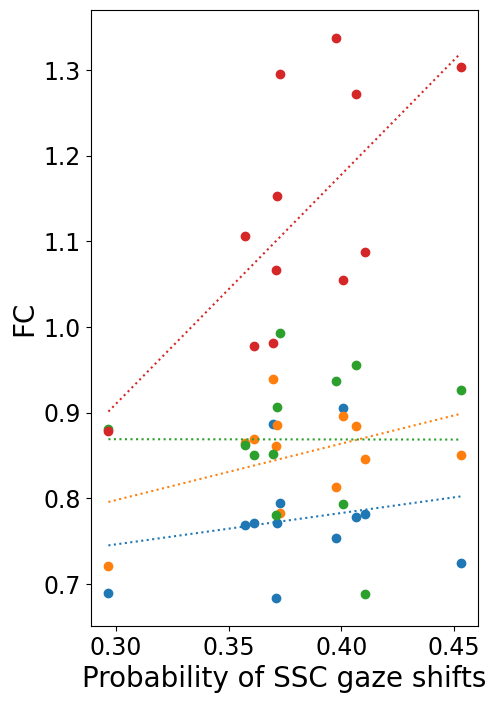

In [25]:
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_voluntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_voluntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc6, label='L-PCL/MC')
a, b = regression(prob_voluntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc35, label='R-LTL')
a, b = regression(prob_voluntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc37, label='R-SPL')
a, b = regression(prob_voluntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.xlabel('Probability of SSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig5', 'FC_vs_prob_eye_voluntary.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

/home/kazu/shared_response/figures/fig5/FC_vs_prob_eye_involuntary.pdf


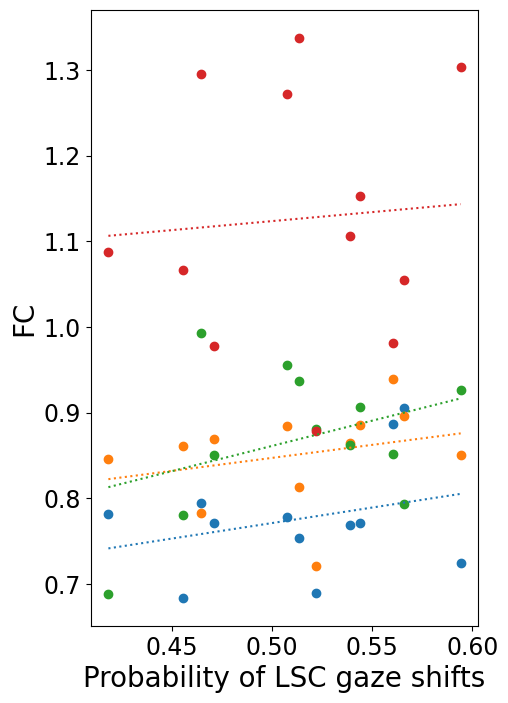

In [26]:
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_involuntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_involuntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc6, label='L-PCL/MC')
a, b = regression(prob_involuntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc35, label='R-LTL')
a, b = regression(prob_involuntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc37, label='R-SPL')
a, b = regression(prob_involuntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.xlabel('Probability of LSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig5', 'FC_vs_prob_eye_involuntary.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import os
from voluntary_fixation.envs import TR, MOVIE_FPS, EYEMOVE_ROOT, SAVE_ROOT, SUBJECT_IDS

SAVE_ROOT = '../../' + SAVE_ROOT
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 20 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 20 # 軸だけ変更されます

/home/kazu/shared_response/figures/fig5_small/FC_vs_prob_eye_voluntary.pdf
/home/kazu/shared_response/figures/fig5_small/FC_vs_prob_eye_involuntary.pdf


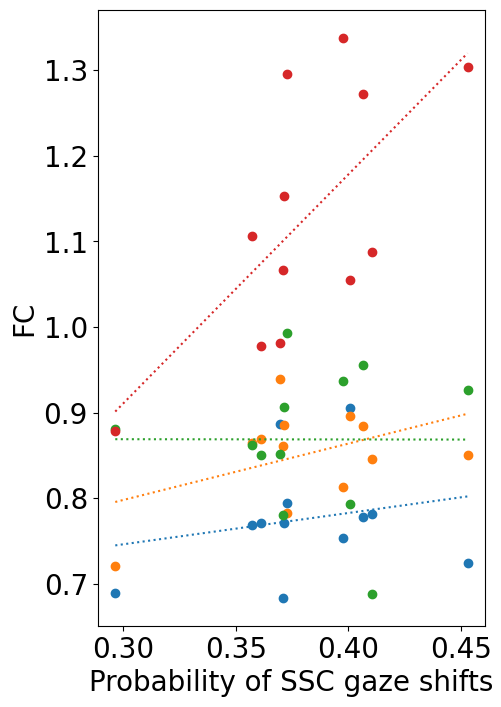

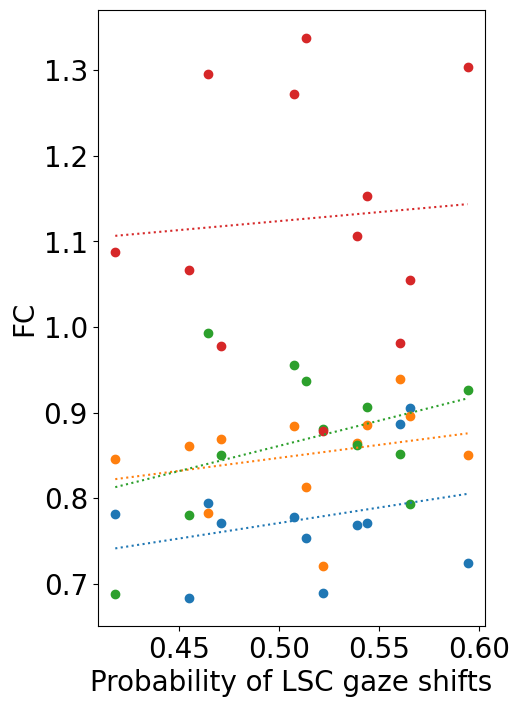

In [28]:
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_voluntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_voluntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc6, label='L-PCL/MC')
a, b = regression(prob_voluntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc35, label='R-LTL')
a, b = regression(prob_voluntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.scatter(prob_voluntary, fc37, label='R-SPL')
a, b = regression(prob_voluntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

plt.xlabel('Probability of SSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig5_small', 'FC_vs_prob_eye_voluntary.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)

print(savepath)
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_involuntary, fc18, label='L-ACC/MPFC')
a, b = regression(prob_involuntary[:,np.newaxis], fc18[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc6, label='L-PCL/MC')
a, b = regression(prob_involuntary[:,np.newaxis], fc6[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc35, label='R-LTL')
a, b = regression(prob_involuntary[:,np.newaxis], fc35[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.scatter(prob_involuntary, fc37, label='R-SPL')
a, b = regression(prob_involuntary[:,np.newaxis], fc37[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

plt.xlabel('Probability of LSC gaze shifts')
plt.ylabel('FC')
# plt.legend(bbox_to_anchor=(0, -0.25), loc='upper left', borderaxespad=0, fontsize=15)
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig5_small', 'FC_vs_prob_eye_involuntary.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

# Leave one subject out cross-validation

In [29]:
prob_voluntary = np.array(prob_vol_eye)
prob_involuntary = np.array(prob_inv_eye)

fc37 = np.load('fc-src36-tgt37-sd-1-td2-iq0.5-sq0.7-nbo.npy')
fc18 = np.load('fc-src36-tgt18-sd-1-td-1-iq0.5-sq0.7-nbo.npy')
fc35 = np.load('fc-src36-tgt35-sd-1-td0-iq0.5-sq0.7-nbo.npy')
fc6  = np.load('fc-src36-tgt6-sd-1-td1-iq0.5-sq0.7-nbo.npy')


num_subjects = len(prob_voluntary)
subject_ids = np.arange(num_subjects)

voluntary_preds37 = []
voluntary_preds18 = []
voluntary_preds35 = []
voluntary_preds6 = []
for s in range(num_subjects):
    # fc37
    x = np.delete(fc37, s)
    y = np.delete(prob_voluntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc37[s] + b
    voluntary_preds37.append(pred)
    # fc18
    x = np.delete(fc18, s)
    y = np.delete(prob_voluntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc18[s] + b
    voluntary_preds18.append(pred)
    # fc35
    x = np.delete(fc35, s)
    y = np.delete(prob_voluntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc35[s] + b
    voluntary_preds35.append(pred)
    # fc6
    x = np.delete(fc6, s)
    y = np.delete(prob_voluntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc6[s] + b
    voluntary_preds6.append(pred)

involuntary_preds37 = []
involuntary_preds18 = []
involuntary_preds35 = []
involuntary_preds6 = []
for s in range(num_subjects):
    # fc37
    x = np.delete(fc37, s)
    y = np.delete(prob_involuntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc37[s] + b
    involuntary_preds37.append(pred)
    # fc18
    x = np.delete(fc18, s)
    y = np.delete(prob_involuntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc18[s] + b
    involuntary_preds18.append(pred)
    # fc35
    x = np.delete(fc35, s)
    y = np.delete(prob_involuntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc35[s] + b
    involuntary_preds35.append(pred)
    # fc6
    x = np.delete(fc6, s)
    y = np.delete(prob_involuntary, s)
    a, b = regression(x[:,np.newaxis], y[:,np.newaxis])
    pred = a*fc6[s] + b
    involuntary_preds6.append(pred)

voluntary_preds37 = np.concatenate(voluntary_preds37)
voluntary_preds18 = np.concatenate(voluntary_preds18)
voluntary_preds35 = np.concatenate(voluntary_preds35)
voluntary_preds6 = np.concatenate(voluntary_preds6)
involuntary_preds37 = np.concatenate(involuntary_preds37)
involuntary_preds18 = np.concatenate(involuntary_preds18)
involuntary_preds35 = np.concatenate(involuntary_preds35)
involuntary_preds6 = np.concatenate(involuntary_preds6)

print(voluntary_preds37)

[0.35236284 0.38673441 0.40609993 0.42503661 0.35319936 0.37024579
 0.37909609 0.37036051 0.41990086 0.40051563 0.36442617 0.35805946]


In [30]:
mae_voluntary37 = np.mean(np.abs(prob_voluntary - voluntary_preds37))
mae_voluntary18 = np.mean(np.abs(prob_voluntary - voluntary_preds18))
mae_voluntary35 = np.mean(np.abs(prob_voluntary - voluntary_preds35))
mae_voluntary6 = np.mean(np.abs(prob_voluntary - voluntary_preds6))

mae_involuntary37 = np.mean(np.abs(prob_involuntary - involuntary_preds37))
mae_involuntary18 = np.mean(np.abs(prob_involuntary - involuntary_preds18))
mae_involuntary35 = np.mean(np.abs(prob_involuntary - involuntary_preds35))
mae_involuntary6 = np.mean(np.abs(prob_involuntary - involuntary_preds6))

print('Voluntary Gaze Shift Prediction MAE:')
print('R-Superior Parietal lobule:', mae_voluntary37)
print('L-Anterior Cingulate and Medial Prefrontal cortex:', mae_voluntary18)
print('R-Lateral Temporal lobe:', mae_voluntary35)
print('L-Paracentral lobular and Mid Cingulate:', mae_voluntary6)
print('Involuntary Gaze Shift Prediction MAE:')
print('R-Superior Parietal lobule:', mae_involuntary37)
print('L-Anterior Cingulate and Medial Prefrontal cortex:', mae_involuntary18)
print('R-Lateral Temporal lobe:', mae_involuntary35)
print('L-Paracentral lobular and Mid Cingulate:', mae_involuntary6)

Voluntary Gaze Shift Prediction MAE:
R-Superior Parietal lobule: 0.0273856397977065
L-Anterior Cingulate and Medial Prefrontal cortex: 0.031727948611631945
R-Lateral Temporal lobe: 0.03334364834881518
L-Paracentral lobular and Mid Cingulate: 0.03631374220543861
Involuntary Gaze Shift Prediction MAE:
R-Superior Parietal lobule: 0.05006667583812069
L-Anterior Cingulate and Medial Prefrontal cortex: 0.046365397991922096
R-Lateral Temporal lobe: 0.052262776728335965
L-Paracentral lobular and Mid Cingulate: 0.050323573545208146


In [31]:
# ========== Null model: leave-one-subject-out mean predictor (no FC) ==========
# 参加者 i を除いた11人の gaze-shift 確率の平均を、そのまま i の予測値とする。
# FC も回帰も使わず、参加者間のばらつきだけを反映する最も素朴なベースライン。
# FC モデルがこれを下回れば「FC は参加者間差について情報を持つ」と言える。
def loso_mean_null_mae(p):
    p = np.asarray(p)
    n = len(p)
    return np.mean([np.abs(p[i] - np.delete(p, i).mean()) for i in range(n)])

null_mae_ssc = loso_mean_null_mae(prob_voluntary)    # SSC (voluntary)
null_mae_lsc = loso_mean_null_mae(prob_involuntary)  # LSC (involuntary)

print('===== Null model (LOSO mean predictor, no FC) =====')
print(f'SSC: null MAE = {null_mae_ssc:.6f}   (std across subjects = {prob_voluntary.std(ddof=1):.4f})')
print(f'LSC: null MAE = {null_mae_lsc:.6f}   (std across subjects = {prob_involuntary.std(ddof=1):.4f})')
print()

print('===== SSC: FC model vs Null =====')
for name, mae in [('R-SPL', mae_voluntary37), ('L-ACC/MPFC', mae_voluntary18),
                  ('R-LTL', mae_voluntary35), ('L-PCL/MC', mae_voluntary6)]:
    verdict = 'BEATS null' if mae < null_mae_ssc else 'does NOT beat null'
    print(f'  {name:11s}: FC MAE = {mae:.6f}  vs null {null_mae_ssc:.6f}  -> {verdict}')

print('===== LSC: FC model vs Null =====')
for name, mae in [('R-SPL', mae_involuntary37), ('L-ACC/MPFC', mae_involuntary18),
                  ('R-LTL', mae_involuntary35), ('L-PCL/MC', mae_involuntary6)]:
    verdict = 'BEATS null' if mae < null_mae_lsc else 'does NOT beat null'
    print(f'  {name:11s}: FC MAE = {mae:.6f}  vs null {null_mae_lsc:.6f}  -> {verdict}')

===== Null model (LOSO mean predictor, no FC) =====
SSC: null MAE = 0.029964   (std across subjects = 0.0379)
LSC: null MAE = 0.045121   (std across subjects = 0.0520)

===== SSC: FC model vs Null =====
  R-SPL      : FC MAE = 0.027386  vs null 0.029964  -> BEATS null
  L-ACC/MPFC : FC MAE = 0.031728  vs null 0.029964  -> does NOT beat null
  R-LTL      : FC MAE = 0.033344  vs null 0.029964  -> does NOT beat null
  L-PCL/MC   : FC MAE = 0.036314  vs null 0.029964  -> does NOT beat null
===== LSC: FC model vs Null =====
  R-SPL      : FC MAE = 0.050067  vs null 0.045121  -> does NOT beat null
  L-ACC/MPFC : FC MAE = 0.046365  vs null 0.045121  -> does NOT beat null
  R-LTL      : FC MAE = 0.052263  vs null 0.045121  -> does NOT beat null
  L-PCL/MC   : FC MAE = 0.050324  vs null 0.045121  -> does NOT beat null


In [32]:
# ========== Permutation test: FC-based LOSO prediction は偶然より良いか ==========
# 被験者ラベルを shuffle して FC-behavior 対応を壊し、同じ LOSO 回帰で MAE を再計算 -> null 分布。
# 観測 MAE がその null 分布の下側何%か (= p 値)。小さいほど「偶然では出ない予測精度」。
def loso_fc_mae(fc, p):
    fc = np.asarray(fc, float); p = np.asarray(p, float); preds = []
    for i in range(len(p)):
        x = np.delete(fc, i); y = np.delete(p, i)
        s = np.cov(x, y, ddof=1)[0, 1] / np.var(x, ddof=1)   # sklearn 1-feature regression と一致
        b = y.mean() - s * x.mean()
        preds.append(s * fc[i] + b)
    return np.mean(np.abs(p - np.array(preds)))

def perm_test(fc, p, n_perm=10000, seed=0):
    rng = np.random.default_rng(seed)
    obs = loso_fc_mae(fc, p)
    null = np.array([loso_fc_mae(fc, rng.permutation(p)) for _ in range(n_perm)])
    pval = (np.sum(null <= obs) + 1) / (n_perm + 1)   # lower MAE = better
    pctl = np.mean(null < obs) * 100                  # 観測が null の下側何%
    return obs, pval, pctl

regions = [('R-SPL', fc37), ('L-ACC/MPFC', fc18), ('R-LTL', fc35), ('L-PCL/MC', fc6)]
n_perm = 10000
print(f'Permutation test (n_perm={n_perm}, statistic = LOSO FC-regression MAE, lower=better)\n')
for cond, p in [('SSC', prob_voluntary), ('LSC', prob_involuntary)]:
    print(f'===== {cond} =====')
    for name, fc in regions:
        obs, pval, pctl = perm_test(fc, p, n_perm=n_perm, seed=0)
        star = ' *' if pval < 0.05 else ''
        print(f'  {name:11s}: MAE={obs:.6f}  p={pval:.4f}  (null 下側 {pctl:.1f}%){star}')
    print()

Permutation test (n_perm=10000, statistic = LOSO FC-regression MAE, lower=better)

===== SSC =====
  R-SPL      : MAE=0.027386  p=0.0763  (null 下側 7.6%)
  L-ACC/MPFC : MAE=0.031728  p=0.4315  (null 下側 43.1%)
  R-LTL      : MAE=0.033344  p=0.7158  (null 下側 71.6%)
  L-PCL/MC   : MAE=0.036314  p=0.9236  (null 下側 92.4%)

===== LSC =====
  R-SPL      : MAE=0.050067  p=0.7131  (null 下側 71.3%)
  L-ACC/MPFC : MAE=0.046365  p=0.2660  (null 下側 26.6%)
  R-LTL      : MAE=0.052263  p=0.8974  (null 下側 89.7%)
  L-PCL/MC   : MAE=0.050324  p=0.6433  (null 下側 64.3%)



In [33]:
# ========== Per-subject sign test / Wilcoxon: FC model vs Null (R-SPL) ==========
# 平均MAEでは差が小さくても、12人中どれだけで FC の方が誤差が小さいか(符号の一致)を見る。
# 「大半で悪化・少数で大幅改善」なら平均は勝っても符号検定は効かない。方向は Fig.5b から事前に固定。
from scipy.stats import wilcoxon

def loso_null_preds(p):
    p = np.asarray(p, float)
    return np.array([np.delete(p, i).mean() for i in range(len(p))])

for cond, p, fc_preds in [('SSC', prob_voluntary, voluntary_preds37),
                          ('LSC', prob_involuntary, involuntary_preds37)]:
    err_fc   = np.abs(p - fc_preds)             # R-SPL FC model の per-subject 絶対誤差
    err_null = np.abs(p - loso_null_preds(p))   # 平均予測器の per-subject 絶対誤差
    d = err_null - err_fc                        # >0 = その被験者では FC の方が良い
    w = wilcoxon(err_fc, err_null, alternative='less')  # 片側: FC < null
    print(f'===== {cond} (R-SPL) =====')
    print(f'  FC better in {(d > 0).sum()}/{len(p)} subjects,  median(d) = {np.median(d):+.5f}')
    print(f'  mean |err| : FC = {err_fc.mean():.5f},  null = {err_null.mean():.5f}')
    print(f'  Wilcoxon (one-sided, FC < null): W = {w.statistic:.1f},  p = {w.pvalue:.4f}')
    print()

===== SSC (R-SPL) =====
  FC better in 6/12 subjects,  median(d) = -0.00074
  mean |err| : FC = 0.02739,  null = 0.02996
  Wilcoxon (one-sided, FC < null): W = 34.0,  p = 0.3667

===== LSC (R-SPL) =====
  FC better in 3/12 subjects,  median(d) = -0.00430
  mean |err| : FC = 0.05007,  null = 0.04512
  Wilcoxon (one-sided, FC < null): W = 68.0,  p = 0.9919



In [34]:
# ========== Correlation jackknife (leave-one-subject-out r) ==========
# N=12 では1〜2点のレバレッジで r が動く。各被験者を1人ずつ除いて r を再計算し範囲を見る。
#   r が 0.55〜0.75 に収まる -> 相関は頑健 / r が 0.3 台まで落ちる被験者がいる -> 脆い。
from scipy.stats import pearsonr

fc_by_region = {'R-SPL': fc37, 'L-ACC/MPFC': fc18, 'R-LTL': fc35, 'L-PCL/MC': fc6}
for cond, p in [('SSC', prob_voluntary), ('LSC', prob_involuntary)]:
    print(f'===== {cond}: jackknife of Pearson r =====')
    for name, fc in fc_by_region.items():
        r_full = pearsonr(fc, p)[0]
        r_loo = np.array([pearsonr(np.delete(fc, i), np.delete(p, i))[0] for i in range(len(p))])
        i_min = int(r_loo.argmin())
        print(f'  {name:11s}: r_full={r_full:+.3f}  LOO r in [{r_loo.min():+.3f}, {r_loo.max():+.3f}]'
              f'  (most influential: drop sub-{SUBJECT_IDS[i_min]} -> r={r_loo.min():+.3f})')
    print()

===== SSC: jackknife of Pearson r =====
  R-SPL      : r_full=+0.684  LOO r in [+0.520, +0.761]  (most influential: drop sub-19 -> r=+0.520)
  L-ACC/MPFC : r_full=+0.209  LOO r in [-0.117, +0.459]  (most influential: drop sub-19 -> r=-0.117)
  R-LTL      : r_full=-0.001  LOO r in [-0.166, +0.228]  (most influential: drop sub-17 -> r=-0.166)
  L-PCL/MC   : r_full=+0.438  LOO r in [-0.129, +0.555]  (most influential: drop sub-19 -> r=-0.129)

===== LSC: jackknife of Pearson r =====
  R-SPL      : r_full=+0.074  LOO r in [-0.138, +0.201]  (most influential: drop sub-17 -> r=-0.138)
  L-ACC/MPFC : r_full=+0.283  LOO r in [+0.116, +0.479]  (most influential: drop sub-18 -> r=+0.116)
  R-LTL      : r_full=+0.361  LOO r in [-0.038, +0.585]  (most influential: drop sub-15 -> r=-0.038)
  L-PCL/MC   : r_full=+0.277  LOO r in [+0.163, +0.456]  (most influential: drop sub-01 -> r=+0.163)



In [35]:
# ========== Full-sample (N=12) Pearson & Spearman correlation ==========
# レバレッジ/線形性の仮定に依存しないか確認するため、順位相関(Spearman)も併記する。
from scipy.stats import pearsonr, spearmanr

fc_by_region = {'R-SPL': fc37, 'L-ACC/MPFC': fc18, 'R-LTL': fc35, 'L-PCL/MC': fc6}
for cond, p in [('SSC', prob_voluntary), ('LSC', prob_involuntary)]:
    print(f'===== {cond} (N=12) =====')
    for name, fc in fc_by_region.items():
        pr, pp = pearsonr(fc, p)
        sr, sp = spearmanr(fc, p)
        print(f'  {name:11s}: Pearson r={pr:+.3f} (p={pp:.4f})   Spearman rho={sr:+.3f} (p={sp:.4f})')
    print()

===== SSC (N=12) =====
  R-SPL      : Pearson r=+0.684 (p=0.0141)   Spearman rho=+0.622 (p=0.0307)
  L-ACC/MPFC : Pearson r=+0.209 (p=0.5154)   Spearman rho=+0.252 (p=0.4299)
  R-LTL      : Pearson r=-0.001 (p=0.9970)   Spearman rho=+0.154 (p=0.6331)
  L-PCL/MC   : Pearson r=+0.438 (p=0.1544)   Spearman rho=+0.007 (p=0.9828)

===== LSC (N=12) =====
  R-SPL      : Pearson r=+0.074 (p=0.8198)   Spearman rho=+0.035 (p=0.9141)
  L-ACC/MPFC : Pearson r=+0.283 (p=0.3724)   Spearman rho=+0.084 (p=0.7954)
  R-LTL      : Pearson r=+0.361 (p=0.2488)   Spearman rho=+0.175 (p=0.5868)
  L-PCL/MC   : Pearson r=+0.277 (p=0.3832)   Spearman rho=+0.448 (p=0.1446)



# LOSO

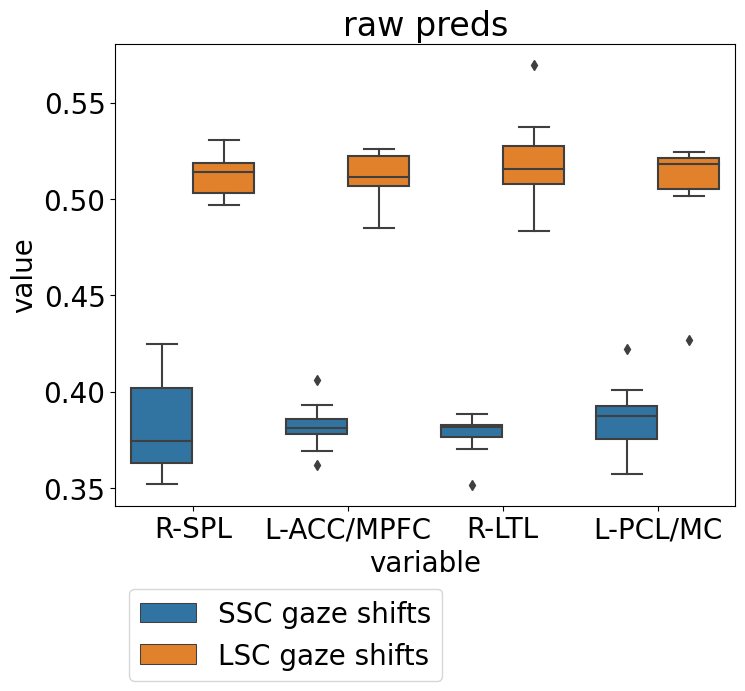

/home/kazu/shared_response/figures/sup_fig7/abserror_prob.pdf
R-SPL - t-statistic: -2.56002175460251, p-value: 0.026517579805476487, mean_SSC: 0.0273856397977065, mean_LSC: 0.05006667583812069
L-ACC/MPFC - t-statistic: -1.4057043819041741, p-value: 0.18742319500056687, mean_SSC: 0.031727948611631945, mean_LSC: 0.046365397991922096
R-LTL - t-statistic: -1.4827451197754409, p-value: 0.16621604699002548, mean_SSC: 0.03334364834881518, mean_LSC: 0.052262776728335965
L-PCL/MC - t-statistic: -1.7300687007002773, p-value: 0.11153723431298426, mean_SSC: 0.03631374220543861, mean_LSC: 0.050323573545208146


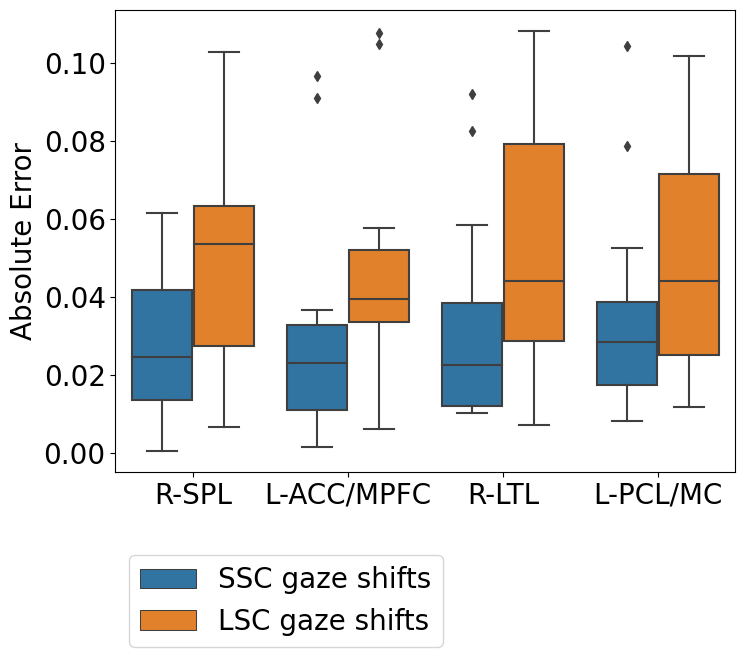

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


plot_df = {
    'R-SPL': np.concatenate([voluntary_preds37, involuntary_preds37]),
    'L-ACC/MPFC': np.concatenate([voluntary_preds18, involuntary_preds18]),
    'R-LTL': np.concatenate([voluntary_preds35, involuntary_preds35]),
    'L-PCL/MC': np.concatenate([voluntary_preds6, involuntary_preds6]),
    'Type': ['SSC gaze shifts']*len(voluntary_preds37) + ['LSC gaze shifts']*len(involuntary_preds37)
}

df = pd.DataFrame(plot_df)

df.to_csv('fc6_loocv_preds20251029.csv', index=False)
# long形式に変換
df_melted = df.melt(id_vars="Type", var_name="variable", value_name="value")

# seabornで描画
plt.figure(figsize=(8,6))
sns.boxplot(x="variable", y="value", hue="Type", data=df_melted)
plt.title("raw preds")
plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left')
plt.show()


plot_df = {
    'R-SPL': np.concatenate([voluntary_preds37, involuntary_preds37]),
    'L-ACC/MPFC': np.concatenate([voluntary_preds18, involuntary_preds18]),
    'R-LTL': np.concatenate([voluntary_preds35, involuntary_preds35]),
    'L-PCL/MC': np.concatenate([voluntary_preds6, involuntary_preds6]),
    'true_value': np.concatenate([prob_voluntary, prob_involuntary]),
    'Type': ['SSC gaze shifts']*len(voluntary_preds37) + ['LSC gaze shifts']*len(involuntary_preds37)
}


df = pd.DataFrame(plot_df)

df['R-SPL'] = df.apply(lambda row: np.abs(row['true_value'] - row['R-SPL']), axis=1)
df['L-ACC/MPFC'] = df.apply(lambda row: np.abs(row['true_value'] - row['L-ACC/MPFC']), axis=1)
df['R-LTL'] = df.apply(lambda row: np.abs(row['true_value'] - row['R-LTL']), axis=1)
df['L-PCL/MC'] = df.apply(lambda row: np.abs(row['true_value'] - row['L-PCL/MC']), axis=1)
df = df.drop(columns=['true_value'])
df.to_csv('fc6_loocv_AbsError_20251029.csv', index=False)
# long形式に変換
df_melted = df.melt(id_vars="Type", var_name="variable", value_name="value")

# seabornで描画
df_melted['Absolute Error'] = df_melted['value']

plt.figure(figsize=(8,6))
ax = sns.boxplot(x="variable", y="Absolute Error", hue="Type", data=df_melted)
ax.set_xlabel(None)
# plt.title("Absolute Error")
plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left')
# plt.show()

savepath =os.path.join('/home/kazu/shared_response/figures', 'sup_fig7', 'abserror_prob.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)



# t検定

## R-SPL
from scipy.stats import ttest_rel
for var in ["R-SPL", "L-ACC/MPFC", "R-LTL", "L-PCL/MC"]:
    a_vals = df.loc[df["Type"] == "SSC gaze shifts", var].reset_index(drop=True)
    b_vals = df.loc[df["Type"] == "LSC gaze shifts", var].reset_index(drop=True)
    t_stat, p_val = ttest_rel(a_vals, b_vals)
    print(f"{var} - t-statistic: {t_stat}, p-value: {p_val}, mean_SSC: {a_vals.mean()}, mean_LSC: {b_vals.mean()}")

In [17]:
# null 仮説検証
